In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../data/framingham.csv')

In [10]:
df.shape

(4240, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [5]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Vamos a ver la distribucion de la variable objetivo 

In [ ]:
df['TenYearCHD'].value_counts() 

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

podemos ver que de 4240 registros, 3596 no tienen riesgo de desarrollar enfermedad coronaria a 10 años, mientras que 644 si tienen riesgo.

A pesar de que el documento nos muestra los datos nulos por columna, vamos a mostrarlos

In [8]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


 # ANÁLISIS UNIVARIADO

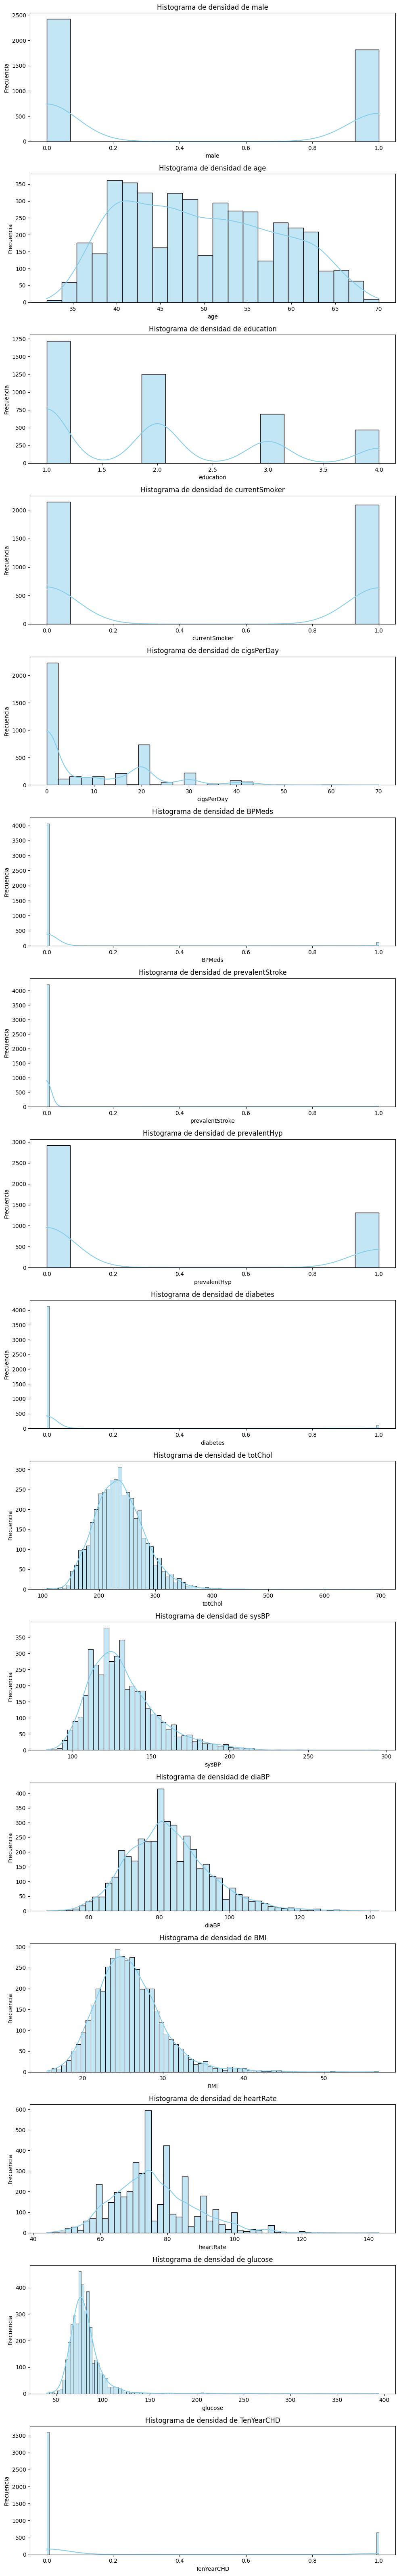

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns #ESTE FRAGMENTO DE CÓDIGO LO HE RECICLADO DEL EDA DE HOTEL BOOKINGS


n_rows = len(numeric_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=1, figsize=(10, 4 * n_rows))


for i, column in enumerate(numeric_cols):
    sns.histplot(df[column].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histograma de densidad de {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Podemos ver que hay columnas que muestran solo dos barras, esto se debe a que son datos del tipo binario y categoricas. También podemos ver que variables como cigarretes perday tienen muchos valores en el 0, y menos valores a medida que la cantidad aumenta, salvando un pico en el 20. Esto lo veremos más a detalle.

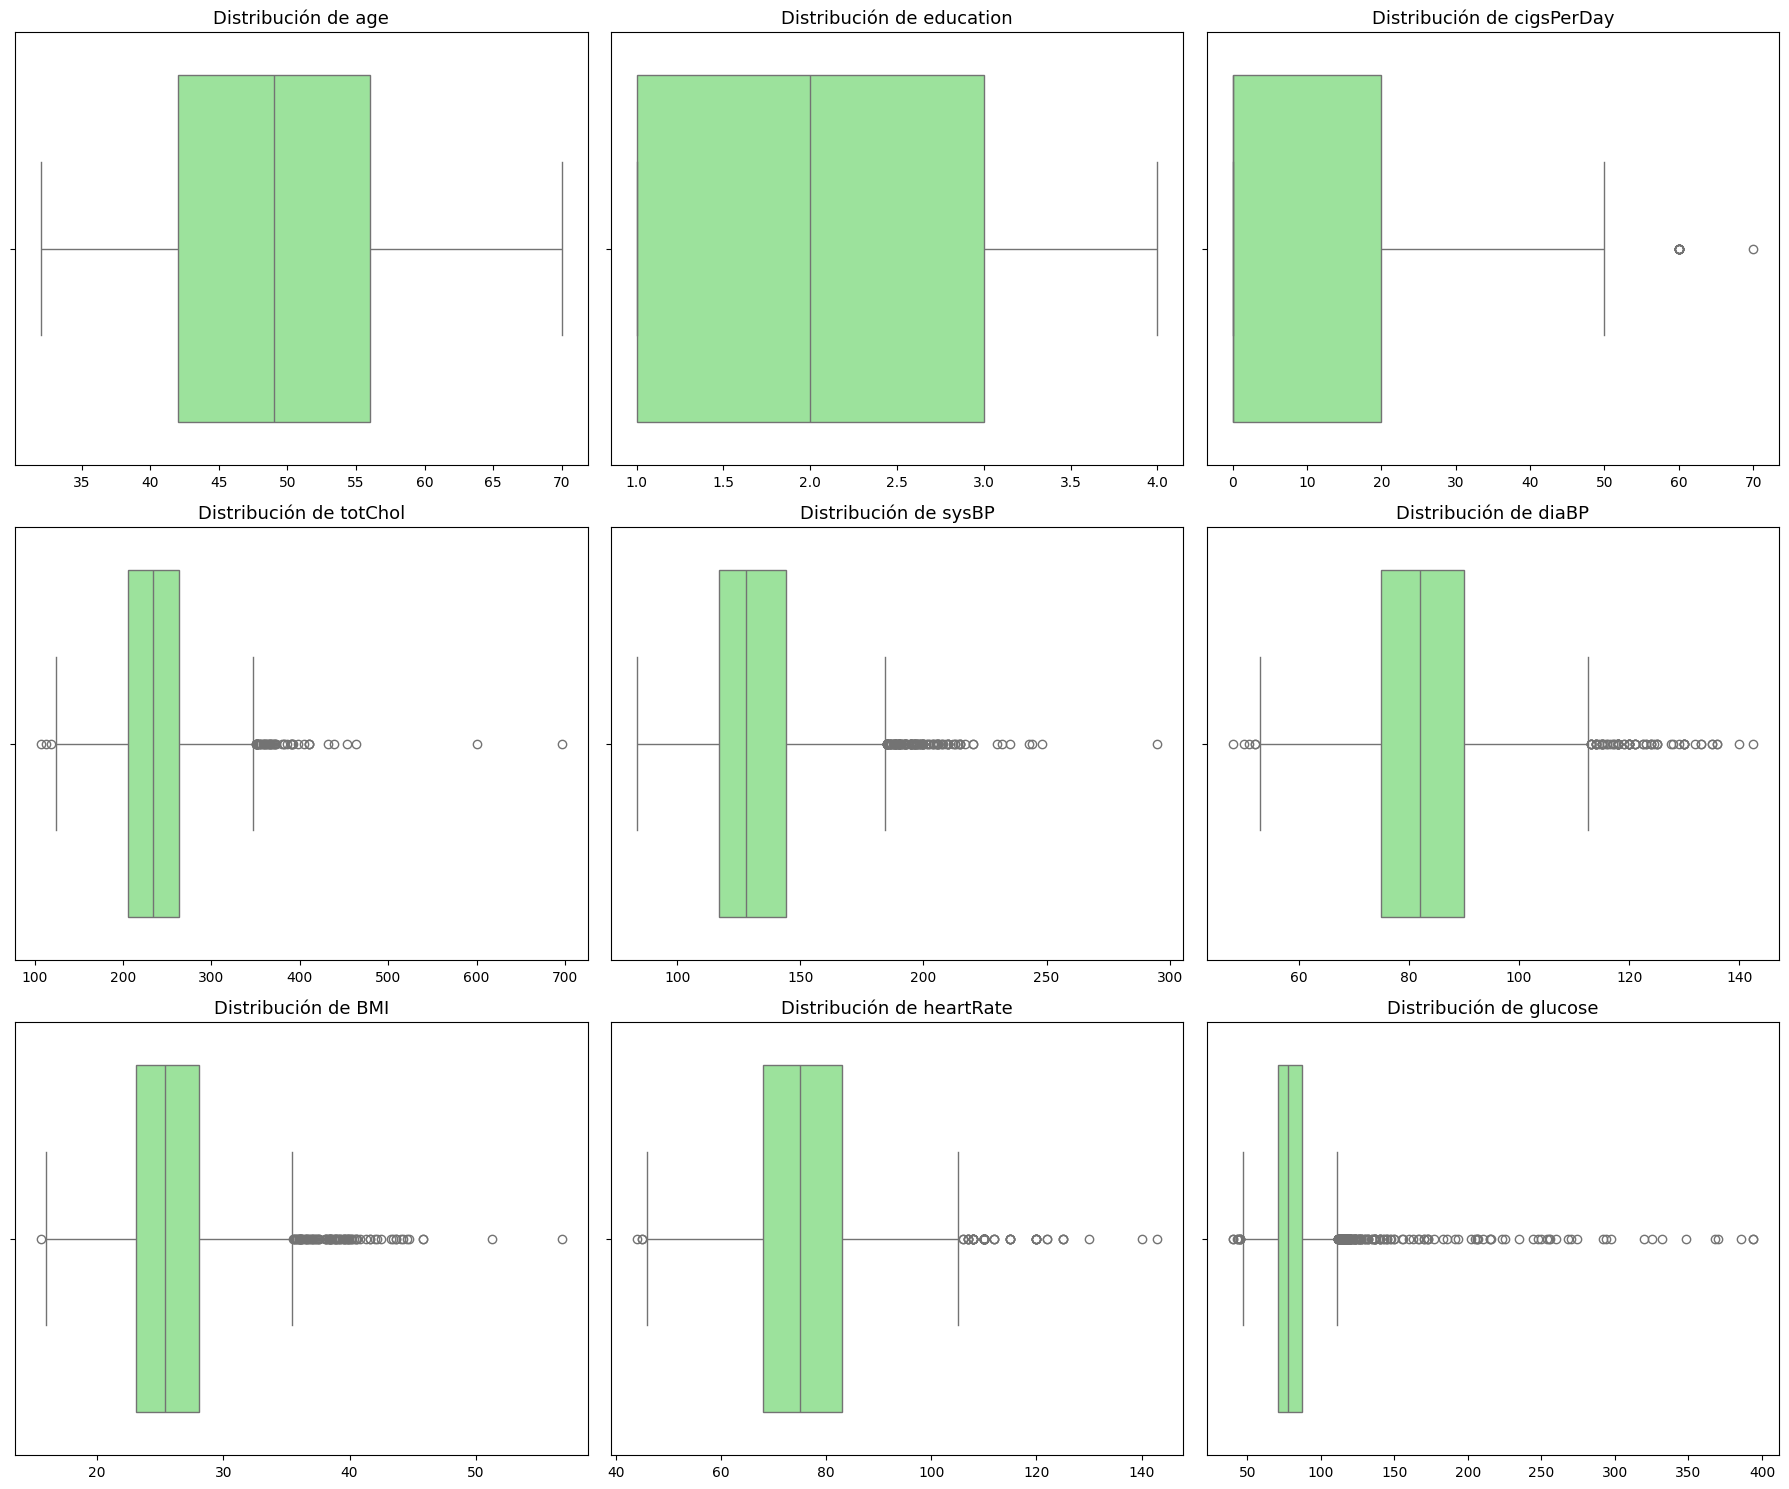

In [14]:


# Esto me lo paso la IA, para que no me haga los boxplots de las variables binarias
no_binarias = [col for col in df.columns if df[col].nunique() > 2]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(no_binarias):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen', fliersize=6)
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

Llama la atención la cantidad de outliers que tiene laa columnas "glucose", "BMI", "sysBP", y "diaBP"

## Análisis de columnas categóricas

Vamos a tener que transformar las variables Bianrias a categóricas para su posterior análisis.

In [15]:

df['male'] = df['male'].astype('object')
df['currentSmoker'] = df['currentSmoker'].astype('object')  
df['BPMeds'] = df['BPMeds'].astype('object')  
df['prevalentStroke'] = df['prevalentStroke'].astype('object')  
df['prevalentHyp'] = df['prevalentHyp'].astype('object')  
df['diabetes'] = df['diabetes'].astype('object')  
df['TenYearCHD'] = df['TenYearCHD'].astype('object')  

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   object 
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   object 
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   object 
 6   prevalentStroke  4240 non-null   object 
 7   prevalentHyp     4240 non-null   object 
 8   diabetes         4240 non-null   object 
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   object 
dtypes: float64(8), int64(1), object(7)
memory usage: 530.1+ KB


Ahora podemos hacer el análisis univariante de las categóricas usando gráficos de barras

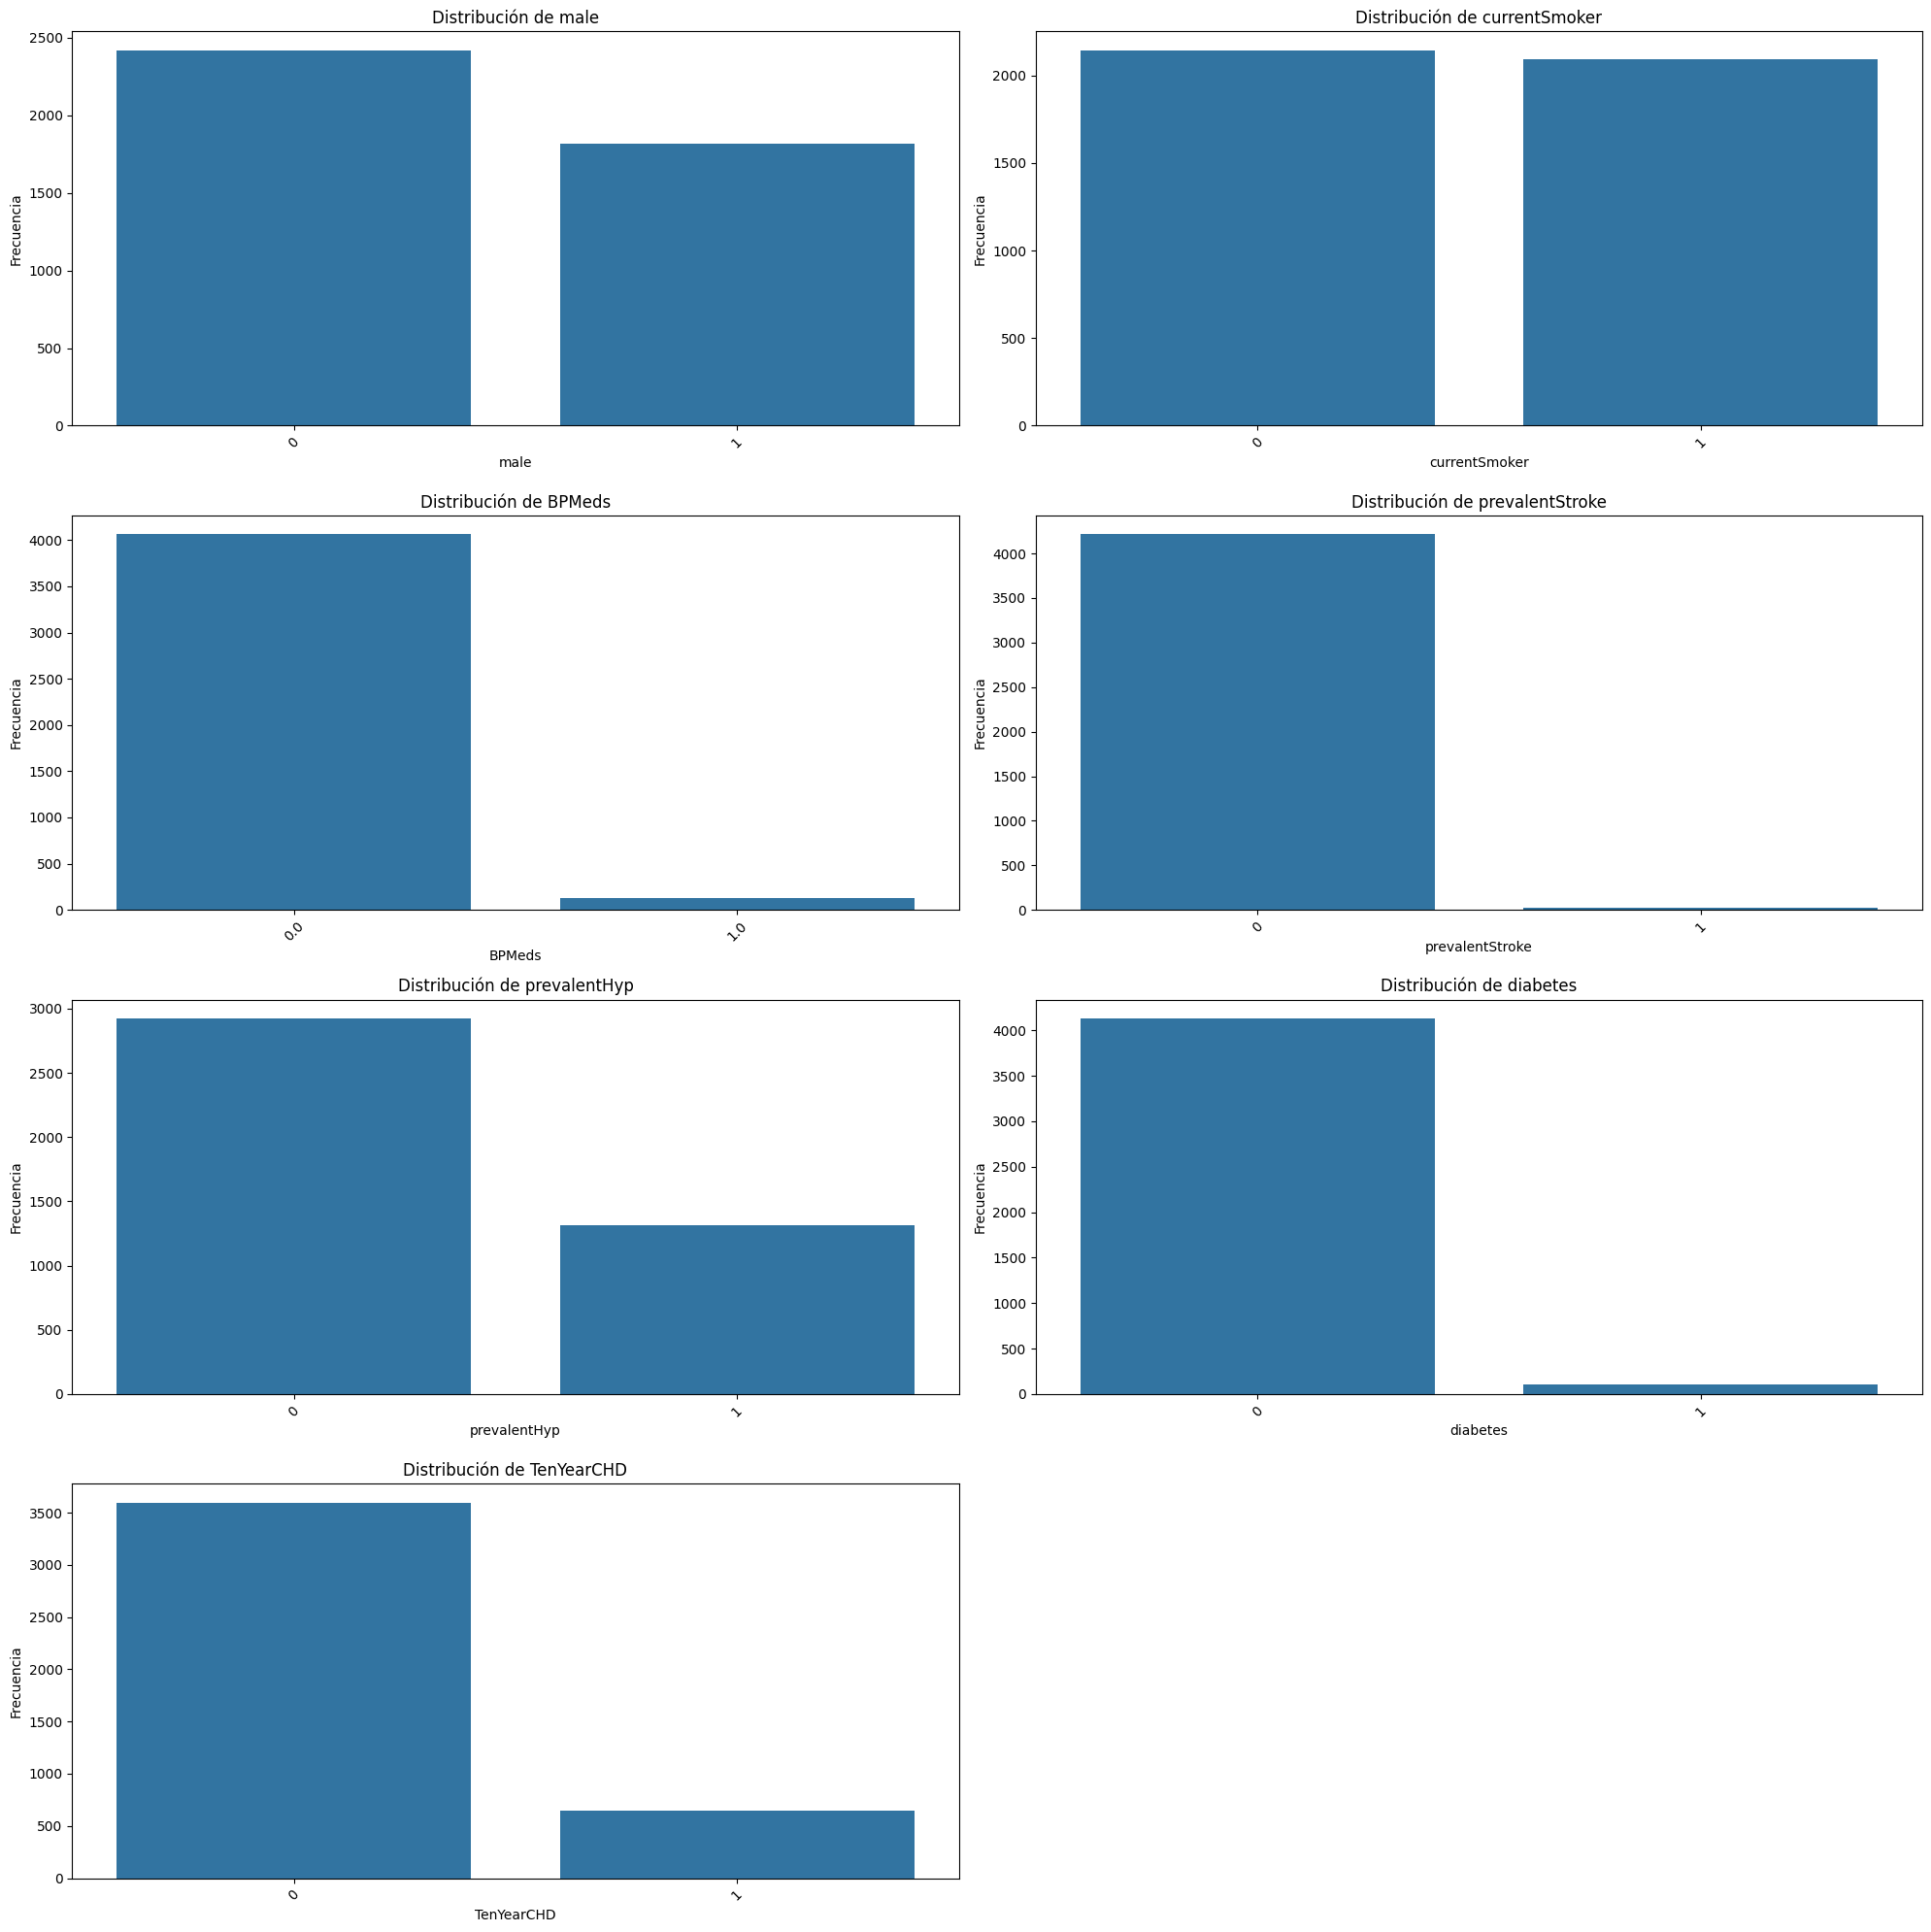

In [19]:


str_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 
            'prevalentHyp', 'diabetes', 'TenYearCHD']

fig, axs = plt.subplots(nrows=len(str_cols) // 2 + len(str_cols) % 2, ncols=2, figsize=(20, 5 * (len(str_cols) // 2 + len(str_cols) % 2)))

# Aplanar el array de ejes para iterar fácilmente
axs = axs.flatten()

for i, col in enumerate(str_cols):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Eliminar subplots vacíos si el número de columnas es impar
if len(str_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()



Se puede observar que hay columnas con un claro desbalance, como los pacientes que han sufrido previamente un ictus. También se puede ver en la columna de "diabetes", donde solo una minoria la padece. 

### Tratamiento de nulos y outliers para posterior visualización

#### Nulos

In [21]:
df['glucose'] = df['glucose'].fillna(df['glucose'].median())
df['totChol'] = df['totChol'].fillna(df['totChol'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].median())
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
#imputaremos por la mediana las variables que no sean binarias

In [22]:
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])

#para las variables binarias, imputaremos los nulos con la moda 

C:\Users\User\AppData\Local\Temp\ipykernel_1148\2903789269.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])


In [23]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64
